In [120]:
import jax
import jax.numpy as jnp

from scoresbibm.src.utils.data_utils import load_model
from scoresbibm.src.tasks.all_conditional_tasks import TwoMoonsAllConditionalTask, SLCPAllConditionalTask

import matplotlib.pyplot as plt

In [114]:
model = load_model("../results/benchmark/",14)

In [96]:
# def score_fn(params ,t ,x ,node_id ,condition_mask ,edge_mask=None):
#     # Zero out condition_mask
#     condition_mask = jnp.zeros_like(condition_mask)
#     return model.model_fn(params,t,x,node_id,condition_mask,edge_mask)


# Repaint method
def score_fn(params ,t ,x ,node_id ,condition_mask ,edge_mask=None):
    # Zero out condition_mask
    condition_mask = jnp.zeros_like(condition_mask)
    return model.model_fn(params,t,x,node_id,condition_mask,edge_mask)

In [97]:
#model.set_default_score_fn(score_fn)

In [121]:
task = SLCPAllConditionalTask()
reference_sampler = task.get_reference_sampler()
joint_sampler = task.get_joint_sampler()
observation_stream = task.get_observation_generator()(jax.random.PRNGKey(0))

In [99]:
# joint_sample = joint_sampler(jax.random.PRNGKey(0))
# condition_mask = jnp.array([False, False, True, False])
# x_o = jnp.concatenate([joint_sample[task.var_names[i]] for i in range(4) if condition_mask[i]])

In [122]:
from sbi.analysis.sbc import c2st 
import torch
import numpy as np


In [136]:
for _ in range(1):
    condition_mask, x_o, t_o = next(observation_stream)
    samples = model.sample(2000, x_o= x_o,condition_mask=condition_mask, rng=jax.random.PRNGKey(0))
    samples_ref = reference_sampler.sample(2000, x_o= x_o,condition_mask=condition_mask,rng=jax.random.PRNGKey(1))  
    print(c2st(torch.tensor(np.array(samples)),torch.tensor(np.array(samples_ref))))

tensor([0.8665])


In [137]:
print(condition_mask)

[False False False False False  True  True  True  True  True  True  True
  True]


In [138]:
from sbi.analysis import pairplot
import numpy as np

(<Figure size 1000x1000 with 25 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: xlabel='dim 3'>, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='dim 4'>, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='dim 5'>]],
       dtype=object))

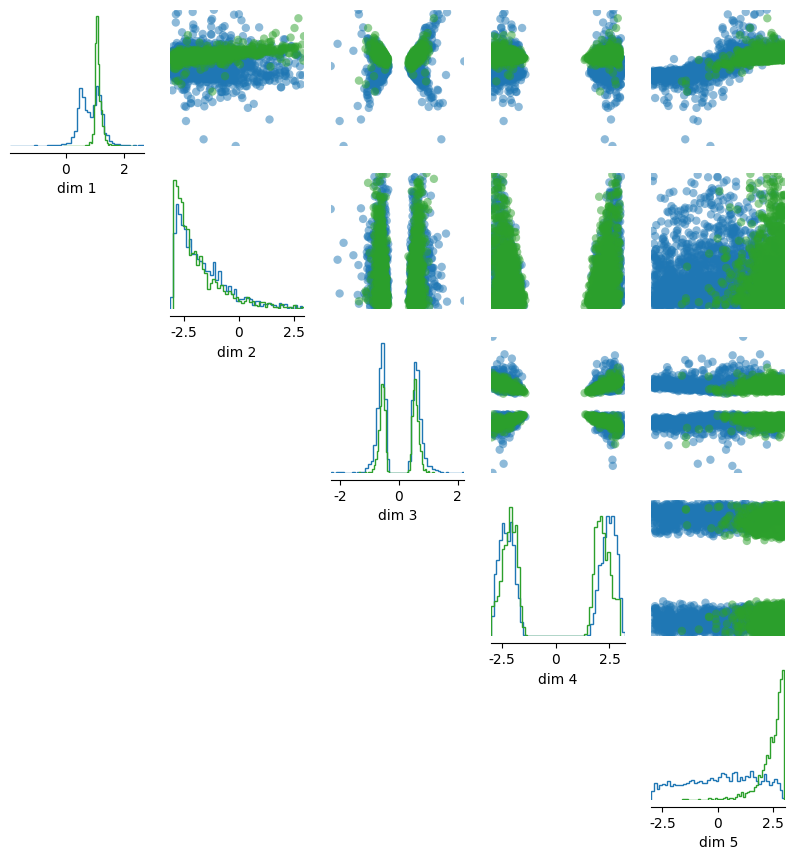

In [139]:
pairplot([np.array(samples),np.array(samples_ref)], upper="scatter")

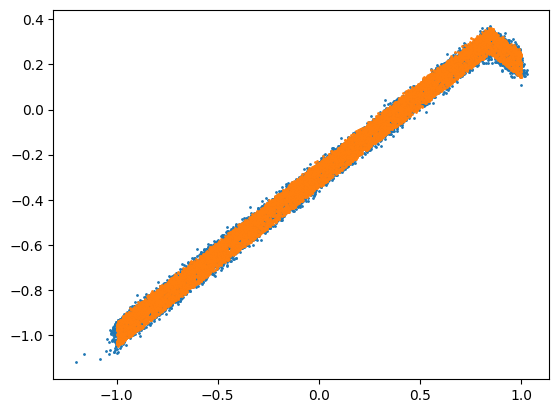

In [58]:
plt.scatter(samples[:,0],samples[:,1], s=1.)
plt.scatter(samples_ref[:,0],samples_ref[:,1], s=1.)